(fin-edu:investing:mpt-capm:correlation)=
# Correlation between Assets in MPT and CAPM Models

In this section, the effects of correlation between assets are discussed in a few-asset portfolio.

In [13]:
"""
Modern Portfolio Theory
Effect of the correlation in a 2-asset portfolio

"""

import numpy as np
from scipy.optimize import minimize
from functools import partial

import matplotlib.pyplot as plt


In [69]:
#> Dictionary collecting different assets for building portfolio
ptfs = {}

#> 1. Two-asset portfolio
# Here, un-correlated assets, r12 = 0
#> Expected returns and covariance
mu1, mu2 =  5., 10.
si1, si2 =  6., 15.
r12  = .0

mu = np.array([mu1, mu2])

si_fun = lambda r12: np.array([
        [      si1**2, si1*si2*r12],
        [ si1*si2*r12,      si2**2]
    ])

ptfs['risky'] = { 'mu': mu, 'si_fun': si_fun, 'marker': 'x' }
ptfs['risky']['w/o risk-free'] = None



#> 2. Three-asset portfolio
# The same as the two-asset portfolio above, with an extra risk-free asset
# (risk-free = zero variance, si3 = .0)
#> Expected returns and covariance
mu1, mu2, mu3 = 5., 10.,  3.
si1, si2, si3 = 6., 15.,  0.
r12, r13, r23 = .0, .0, .0

mu = np.array([mu1, mu2, mu3])
si_fun = lambda r12: np.array([
    [      si1**2, si1*si2*r12,     .0 ],
    [          .0,      si2**2,     .0 ],
    [          .0,          .0, si3**2 ]
])

ptfs['with risk-free'] = { 'mu': mu, 'si_fun': si_fun, 'marker': 's' }
ptfs['with risk-free']['w/o risk-free'] = 'risky'




**Useful arrays and functions.** Functions to be used in the optimization are defined here. The optimization process aims at finding the asset allocation with minimum variance of the return, given the expected value of the return. 

In [70]:
# Find min, max returns for plots
mu_v = np.concatenate( [ i['mu'] for k,i in ptfs.items() ] )

min_mu = np.min(mu_v) 
max_mu = np.max(mu_v) + 2.0

#> MPT
# An optimization problem is solved for a set of desired return to find the efficient
# frontier of a portfolio, under the assumptions of MPT

#> Array of desired returns, between min and max return of single assets
# des_ret_v = np.linspace(min_mu, max_mu, 30)

#> Constraints
def eq_desired_return(x, mu, desired_ret):
    return np.sum( x * mu ) - desired_ret

def eq_weight_sum(x):
    return np.sum(x) - 1

#> Objective function
def ptf_var(x, sigma):
    return x.T @ sigma @ x

In [81]:

n_des_return = 30
n_corr = 9

for kptf, ptf in ptfs.items():

    n_assets = len(ptf['mu'])

    ptf['wmat'] = []
    ptf['min_sig'] = []
    ptf['des_return'] = np.linspace(np.min(ptf['mu']) - 2. , np.max(ptf['mu']) + 2., n_des_return)
    ptf['corr'] = np.linspace(-1., 1., n_corr)
    ptf['des_ret'] = []


    
    for corr in ptf['corr']:
        for desired_ret in ptf['des_return']:

            #> Constraints (just comment if you don't want some)
            eq_cons = [
                {'type':   'eq', 'fun': partial(eq_desired_return, mu=ptf['mu'], desired_ret=desired_ret)},
                {'type':   'eq', 'fun': eq_weight_sum},     # sum(w) = 1 (fully invested)
            ]
            # eq_cons += [ {'type': 'ineq', 'fun': lambda x:   x[i]} for i in np.arange(n_assets) ]
            # eq_cons += [ {'type': 'ineq', 'fun': lambda x: 1-x[i]} for i in np.arange(n_assets) ]
    
            cost_fun = partial(ptf_var, sigma=ptf['si_fun'](corr))
    
            x0 = np.zeros(n_assets); x0[0] = 1  #  np.ones(3) / 3.
            res = minimize(cost_fun, x0, constraints=eq_cons,)
    
            # print(f"Desired Return: {desired_ret}, res: {res.x}")
    
            ptf_si = np.sqrt(res.x @ ptf['si_fun'](corr) @ res.x)
            ptf_mu = np.sum(res.x * ptf['mu'])
    
            #> Store weights and min variance, for the desired expected return
            ptf['wmat'] += [ res.x ]
            ptf['min_sig'] += [ ptf_si ]

            ptf['des_ret'] += [ desired_ret ]

            # print(f"des_ret, cor: {desired_ret}, {corr}")
            # print(res.x)

    ptf['wmat'] = np.array(ptf['wmat'])
    ptf['min_sig'] = np.array(ptf['min_sig'])


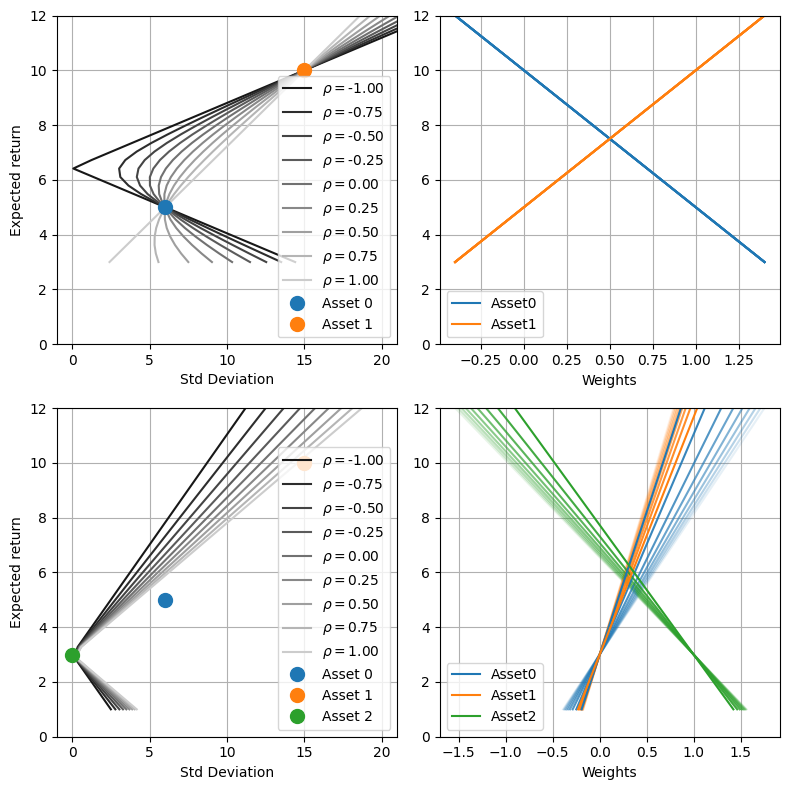

In [93]:
#> Initialize plot
fig, ax = plt.subplots(2, 2, figsize=(8, 8))


cmap = plt.get_cmap('tab10')


nptf = 0
for kptf, ptf in ptfs.items():

    #>
    # si = ptf["si"]
    mu = ptf["mu"]
    
    #> Weights
    wmat = ptf['wmat']
    
    # for kptf, ptf in ptfs.items():
    # ax[nptf,0].plot(ptf['min_sig'], ptf['des_ret'], ptf['marker']+'-', label='Efficient Frontier', color='black', markersize=5,)
    for i_corr in np.arange(n_corr):
        ax[nptf,0].plot(
            ptf['min_sig'][i_corr*n_des_return:(i_corr+1)*n_des_return], 
            ptf['des_ret'][i_corr*n_des_return:(i_corr+1)*n_des_return], 
            ptf['marker']+'-', markersize=0,
            label=f"$\\rho=${ptf['corr'][i_corr]:.2f}",
            color = f"{0.+0.8*(i_corr+1)/n_corr}"
            # color='black', alpha = .0 + 1. * i_corr/n_corr
        )

        
    for iass in np.arange(len(mu)):
         ax[nptf,0].plot(si_fun(.0)[iass,iass]**.5, mu[iass], 'o', markersize=10, label=f'Asset {iass}')
    
    """
    if ( not ptf['w/o risk-free'] == None ):
        ptf_rf = ptfs[ptf['w/o risk-free']]
        # ax[nptf,0].plot(ptf_rf['min_sig'], ptf_rf['des_ret'], ptf_rf['marker']+'-', color='grey', markersize=5,)
        for i_des_return in np.arange(n_des_return):
            ax[nptf,0].plot(
                ptf_rf['min_sig'][i_des_return::n_corr], 
                ptf_rf['des_ret'][i_des_return::n_corr], 
                ptf_rf['marker']+'-', color='grey', markersize=0,
            )
    """
    
    ax[nptf,0].set_xlim([-1, 21])
    ax[nptf,0].set_ylim([ 0, 12])
    # ax[nptf,0].set_ylim([min_mu-.2, max_mu+.2])
    ax[nptf,0].set_xlabel("Std Deviation")
    ax[nptf,0].set_ylabel("Expected return")
    ax[nptf,0].grid()
    ax[nptf,0].legend()

    
    #>
    for i_corr in np.arange(n_corr):

        # for i_des_return in np.arange(n_des_return):

        for i in np.arange(np.shape(wmat)[1]):
            if i_corr == n_corr-1:
                ax[nptf,1].plot(wmat[i_corr*n_des_return:(i_corr+1)*n_des_return,i], ptf['des_ret'][i_corr*n_des_return:(i_corr+1)*n_des_return], alpha=(i_corr+1)/n_corr, color=cmap(i%10), label=f"Asset{i}")
            else:
                ax[nptf,1].plot(wmat[i_corr*n_des_return:(i_corr+1)*n_des_return,i], ptf['des_ret'][i_corr*n_des_return:(i_corr+1)*n_des_return], alpha=(i_corr+1)/n_corr, color=cmap(i%10),)

    ax[nptf,1].set_xlabel("Weights")
    ax[nptf,1].legend(); ax[nptf,1].grid()
    # ax[nptf,1].set_ylim([min_mu-.2, max_mu+.2])
    ax[nptf,1].set_ylim([ 0, 12])

    """
    #> Stacked - with expected return on y
    cum = np.zeros((np.shape(wmat)[0], np.shape(wmat)[1]+1))

    for i in np.arange(1, np.shape(cum)[1]):
        cum[:,i] = cum[:,i-1] + wmat[:,i-1]

    for i in np.arange(1, np.shape(cum)[1]):
        ax[nptf,2].fill_betweenx(ptf['des_ret'], cum[:,i-1], cum[:,i], label=f"Asset{i-1}", alpha = .5)

    ax[nptf,2].legend(); ax[nptf,2].grid()  # loc='upper right'
    ax[nptf,2].set_xlabel('Portfolio composition')
    # ax[nptf,2].set_ylim([min_mu-.2, max_mu+.2])
    ax[nptf,2].set_ylim([ 0, 12])
    """

    nptf += 1

fig.tight_layout()
plt.show()